# 🧪 DreamScape AI — Multimodal Evaluation Notebook (Deliverable 3)

This notebook evaluates the DreamScape AI multimodal pipeline using:
- **Random DreamBank samples**
- **CLIP semantic alignment**
- **Toxicity (Detoxify small model)**
- **Runtime**
- **Per-dream motif graph + moodboard + generated images**

All evaluation artifacts are saved inside:

This notebook requires `multimodal_generation_d3.ipynb` to be present in the same directory.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120

# ----------------------------
# Folder structure (YOUR SETUP)
# ----------------------------
import os
from pathlib import Path

# Notebook-safe root directory logic
# If you're inside /notebooks, repo root is one level up
REPO_ROOT = Path(os.getcwd()).resolve().parents[0]

DATA_RAW = REPO_ROOT / "data" / "raw"
DATA_PROC = REPO_ROOT / "data" / "processed"
RESULTS = REPO_ROOT / "results"

DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PROC.mkdir(parents=True, exist_ok=True)
RESULTS.mkdir(parents=True, exist_ok=True)

print("Repo Root:", REPO_ROOT)
print("Data (processed):", DATA_PROC)
print("Results:", RESULTS)

Repo Root: /Users/saturnine/Desktop/DreamScapeAI
Data (processed): /Users/saturnine/Desktop/DreamScapeAI/data/processed
Results: /Users/saturnine/Desktop/DreamScapeAI/results


## 🔌 Load Multimodal Generation Functions

We reuse the entire pipeline (image, moodboard, audio, NER, motif graph, CLIP, toxicity)  
by running the notebook:

- `multimodal_generation_d3.ipynb`

This exposes:
- `sanitize_prompt(text)`
- `multimodal_with_extras(text, out_dir)`

In [2]:
# Load all helper functions from the multimodal notebook
%run ./multimodal_generation_d3.ipynb

Repo Root: /Users/saturnine/Desktop/DreamScapeAI
Data (processed): /Users/saturnine/Desktop/DreamScapeAI/data/processed
Results: /Users/saturnine/Desktop/DreamScapeAI/results
OUT_DIR: /Users/saturnine/Desktop/DreamScapeAI/results


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded text→image: stabilityai/sd-turbo on mps (dtype=torch.float32); safety=ON
versions => transformers 4.57.3 | torch 2.9.1 | scipy 1.16.3 | hf-hub 0.36.0


Device set to use cpu
Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


🎵 Loaded MusicGen via pipeline: facebook/musicgen-small
🔊 AUDIO_ENGINE active: MusicGen/Transformers(facebook/musicgen-small)


Device set to use cpu


🧩 Motif NER: dslim/bert-base-NER loaded.


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


✅ Loaded CLIP model for semantic alignment: openai/clip-vit-base-patch32 on cpu
🎤 Loaded Faster-Whisper: small on cpu (int8)


## 📄 Load Cleaned DreamBank Dataset

We use the cleaned file from: `notebooks/data/processed/dreambank_clean.json`

In [3]:
clean_path = DATA_PROC / "dreambank_clean.json"

if not clean_path.exists():
    raise FileNotFoundError(
        f"❌ Could not find dreambank_clean.json at:\n{clean_path}"
    )

df = pd.read_json(clean_path)

# Handle column naming differences
if "text" not in df.columns and "report" in df.columns:
    df = df.rename(columns={"report": "text"})

df["text"] = df["text"].astype(str)
df["word_count"] = df["text"].str.split().str.len()

print("Total dreams:", len(df))
df.head(5)[["id", "name", "word_count", "text"]]

Total dreams: 1000


,id,name,word_count,text
0,dorothea,Dorothea: 53 years of dreams,109,I fixed my plate with rice and meat paste then...
1,bea1,Bea 1: a high school student,35,I dreamed that I had to reorganize the periodi...
2,izzy-all,"Izzy (ALL, including non-consecutive)",45,I was at some animal place. If you pick up a c...
3,jasmine-all,"Jasmine (ALL, including non-consecutive)",165,We had bought an SUV like minivan-like type th...
4,mack,Mack: A poor recaller,77,The Tae Kwon Do master is teaching me how to t...


## 🎯 Dream Selection for Evaluation

We evaluate:
- **6 dreams**
- chosen randomly but weighted toward medium-length dreams (40–200 words)

In [4]:
df_pool = df[(df.word_count >= 40) & (df.word_count <= 200)]

eval_df = df_pool.sample(6, random_state=42).reset_index(drop=True)

print("Evaluation pool size:", len(df_pool))
eval_df[["id", "name", "word_count"]]

Evaluation pool size: 609


,id,name,word_count
0,hall_female,"College women, late 1940s",179
1,dorothea,Dorothea: 53 years of dreams,71
2,pegasus,Pegasus: a factory worker,123
3,izzy-all,"Izzy (ALL, including non-consecutive)",69
4,norms-f,Hall/VdC Norms: Female,103
5,norms-m,Hall/VdC Norms: Male,86


## 🚀 Run Full Evaluation Per Dream

For each dream:

- Generate **1 main image**
- Generate **6-image moodboard**
- Generate **motif graph**
- Compute **CLIP score**
- Compute **Toxicity score**
- Measure **Runtime**

All artifacts saved under:  `results/eval_multimodal_d3/<dream_id>/`

In [5]:
import time

records = []

print("\nStarting evaluation...\n")

for idx, row in eval_df.iterrows():
    dream_id = row["id"]
    dream_name = row["name"]
    dream_text = row["text"]

    print(f"\n--- Dream {idx+1}/6 ---")
    print(f"ID: {dream_id} | Name: {dream_name} | Words: {row['word_count']}")
    print(dream_text[:300], "...\n")

    # Output directory
    out_dir = RESULTS / "eval_multimodal_d3" / dream_id
    out_dir.mkdir(parents=True, exist_ok=True)

    # Run pipeline
    start = time.time()
    meta = multimodal_with_extras(dream_text, out_dir)
    runtime = time.time() - start

    # Record evaluation metrics
    records.append({
        "dream_id": dream_id,
        "name": dream_name,
        "word_count": row["word_count"],
        "toxicity": meta["toxicity_score"],
        "clip_score": meta["clip_score"],
        "runtime_sec": runtime,
    })

    print(f"Toxicity: {meta['toxicity_score']:.3f}")
    print(f"CLIP alignment: {meta['clip_score']}")
    print(f"Runtime: {runtime:.1f} sec")


Starting evaluation...


--- Dream 1/6 ---
ID: hall_female | Name: College women, late 1940s | Words: 179
There were two girls and myself sitting around a table in H-- Hall. We were watching a fellow and girl come down the steps. Each of us knew the fellow and one by one we told each other of our experiences with him. Each story was similar to the other. There was a fourth vacant chair and we expected t ...



Token indices sequence length is longer than the specified maximum sequence length for this model (155 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['there was a fourth vacant chair and we expected the girl he was with to fill it. < br />< br />< table border =" 1 " cellspacing =" 0 " cellpadding =" 3 ">< tr valign =" top ">< td >< i > interpretation </ i >< br /> i went all summer with the fellow in the dream. there are']


  0%|          | 0/4 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['/>< br />< table border =" 1 " cellspacing =" 0 " cellpadding =" 3 ">< tr valign =" top ">< td >< i > interpretation </ i >< br /> i went all summer with the fellow in the dream. there are two other girls i know who have gone with him in the past and have had the same outcome - when he feels both are getting too serious, he stops dating the girl because he can see himself with a girlfriend but not a wife. now he is going with a fourth girl who probably we all unconsciously hope or expect to end up the same way as we did.</ td > < td >< i > answers to questions </ i >< br /> 2. complete relaxation. fun over conversations.< br /> 3. actual participant.< br /> 4. pleasant.< br /> 5. h -- hall < br /> 6. no.< br /> 7. no.</ td ></ tr ></ table >. style : surreal cinematic volumetric light']


  0%|          | 0/4 [00:00<?, ?it/s]

...

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["program was over. i was finally called to answer a question. i can 't remember what the question was or how i answered.. style : minimalist muted palette"]


  0%|          | 0/4 [00:00<?, ?it/s]

The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ["program was over. i was finally called to answer a question. i can 't remember what the question was or how i answered.. style : storybook ink & wash"]


  0%|          | 0/4 [00:00<?, ?it/s]

Toxicity: 0.001
CLIP alignment: 0.2014945149421692
Runtime: 57.7 sec


## 💾 Save Results & Show Summary

We now save all evaluation rows into: `notebooks/results/evaluation_multimodal_d3.csv`
Then we compute simple statistics:
- CLIP mean / std
- Toxicity mean
- Runtime mean

In [7]:
eval_df_out = pd.DataFrame(records)

csv_path = RESULTS / "evaluation_multimodal_d3.csv"
eval_df_out.to_csv(csv_path, index=False)

print("Evaluation finished.")
print("Saved evaluation CSV to:", csv_path)
display(eval_df_out)

print("Samples:", len(eval_df_out))
print("Valid CLIP scores:", eval_df_out.clip_score.count())

print("CLIP mean:", round(eval_df_out.clip_score.mean(), 3))
print("CLIP std :", round(eval_df_out.clip_score.std(), 3))

print("Runtime mean:", round(eval_df_out.runtime_sec.mean(), 1), "sec")
print("Runtime std :", round(eval_df_out.runtime_sec.std(), 1), "sec")

Evaluation finished.
Saved evaluation CSV to: /Users/saturnine/Desktop/DreamScapeAI/results/evaluation_multimodal_d3.csv


,dream_id,name,word_count,toxicity,clip_score,runtime_sec
0,hall_female,"College women, late 1940s",179,0.001476,0.263479,58.211834
1,dorothea,Dorothea: 53 years of dreams,71,0.001320,0.229078,56.850267
2,pegasus,Pegasus: a factory worker,123,0.003008,0.283192,56.116399
3,izzy-all,"Izzy (ALL, including non-consecutive)",69,0.098050,0.182381,57.087605
4,norms-f,Hall/VdC Norms: Female,103,0.000758,0.246348,57.812669
5,norms-m,Hall/VdC Norms: Male,86,0.000655,0.201495,57.677025


Samples: 6
Valid CLIP scores: 6
CLIP mean: 0.234
CLIP std : 0.038
Runtime mean: 57.3 sec
Runtime std : 0.8 sec


## 📊 Visualize CLIP Score & Runtime Distribution

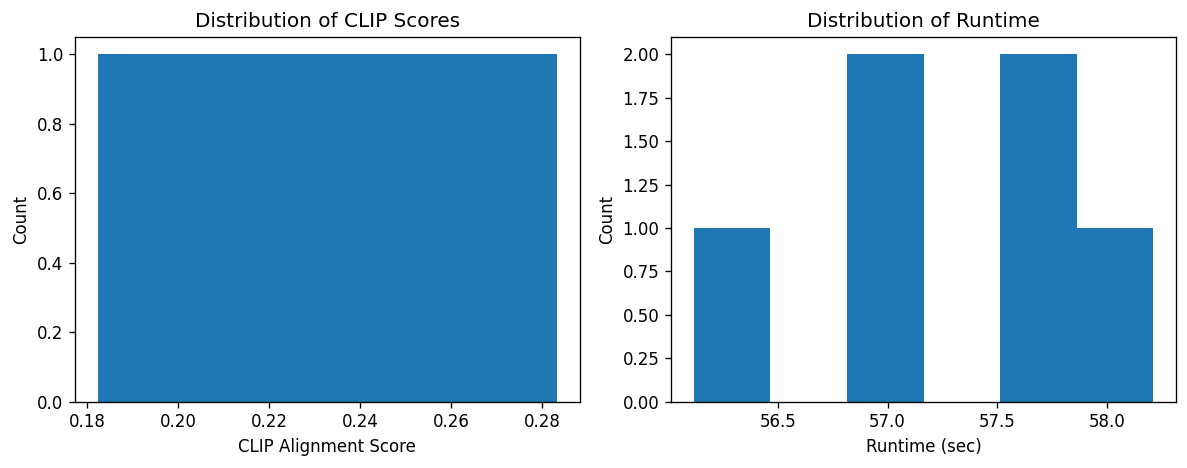

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

# CLIP histogram
ax[0].hist(eval_df_out.clip_score, bins=6)
ax[0].set_title("Distribution of CLIP Scores")
ax[0].set_xlabel("CLIP Alignment Score")
ax[0].set_ylabel("Count")

# Runtime histogram
ax[1].hist(eval_df_out.runtime_sec, bins=6)
ax[1].set_title("Distribution of Runtime")
ax[1].set_xlabel("Runtime (sec)")
ax[1].set_ylabel("Count")

plt.tight_layout()
plt.show()